In [1]:
pip install EMD-signal

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import PyEMD
print(PyEMD.__version__)

1.6.4


In [ ]:
import matplotlib.pyplot as plt
# 导入matplotlib的pyplot模块，用于数据可视化。
import tensorflow as tf
# 导入tensorflow库，用于深度学习模型的构建和训练
from PyEMD import EMD, EEMD, CEEMDAN
# 从pyemd库导入EMD, EEMD, CEEMDAN，用于模态分解
import pandas as pd
# 导入pandas库，用于数据处理和分析
import warnings
# 导入warnings库，用于控制警告消息
warnings.filterwarnings("ignore")

In [4]:
gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [5]:
# 用来正常显示中文/英文标签（保持与模板一致）
plt.rcParams['font.sans-serif'] = ['Times New Roman']
# 用来正常显示负号
plt.rcParams['axes.unicode_minus'] = False

In [6]:
df_raw_data = pd.read_csv('CHINA-FloodPrediction.csv')

# 确保时间列为Datetime并按时间排序
df_raw_data['Month'] = pd.to_datetime(df_raw_data['Month'])
df_raw_data = df_raw_data.sort_values('Month').reset_index(drop=True)

# 只分解目标 rx5day（推荐做法）
series_close = pd.Series(
    df_raw_data['rx5day'].astype(float).values,
    index=df_raw_data['Month']
)
# 创建一个pandas的Series对象。
# df_raw_data['rx5day'].values提取'rx5day'列的值作为Series的数据。
# index=df_raw_data['Month']设置Series的索引为时间戳（YYYY-MM）
print(series_close)

Month
1950-01-01     9.29
1950-02-01    13.21
1950-03-01    19.70
1950-04-01    31.72
1950-05-01    45.66
              ...  
2023-08-01    51.60
2023-09-01    39.79
2023-10-01    24.88
2023-11-01    17.64
2023-12-01    11.84
Length: 888, dtype: float64


In [7]:
def ceemdan_decompose(series=None, trials=100):
    # 定义CEEMDAN分解函数。
    # series: 待分解的时间序列数据。
    # trials: CEEMDAN的试验次数，用于生成噪声。

    decom = CEEMDAN()
    # 创建CEEMDAN对象。

    decom.trials = trials
    # 设置CEEMDAN对象的试验次数。

    df_ceemdan = pd.DataFrame(decom(series.values).T)
    # 对时间序列数据执行CEEMDAN分解，并将结果转置后转换为DataFrame。

    df_ceemdan.columns = ['imf' + str(i+1) for i in range(len(df_ceemdan.columns))]
    # 为DataFrame的每一列命名，表示每个内在模态函数（IMF）。

    return df_ceemdan
    # 返回分解结果的DataFrame。

In [8]:
df_ceemdan = ceemdan_decompose(series_close)
# 对series_close进行CEEMDAN分解，并返回结果的DataFrame。

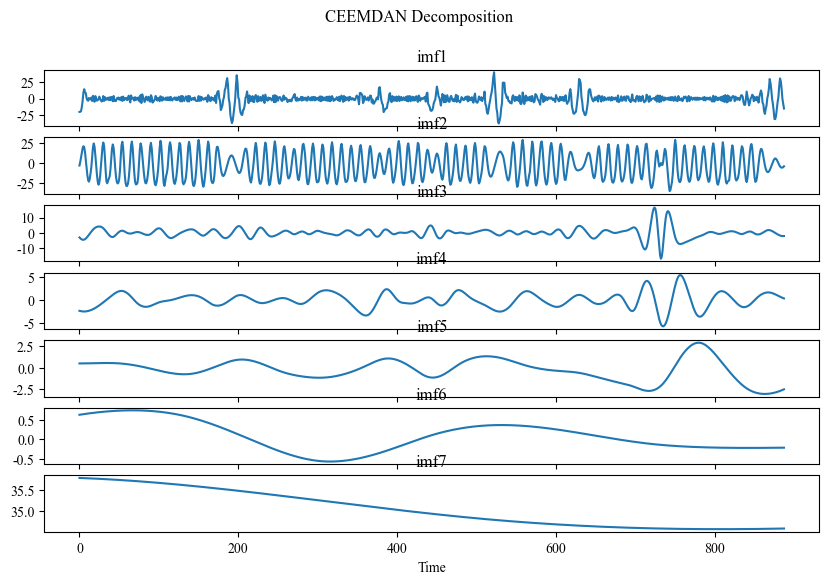

In [9]:
# 可视化VMD分解结果
fig, axs = plt.subplots(nrows=len(df_ceemdan.columns), figsize=(10, 6), sharex=True)
# 创建一个绘图对象和多个子图对象。
for i, col in enumerate(df_ceemdan.columns):
    axs[i].plot(df_ceemdan[col])
    axs[i].set_title(col)
    # 遍历每个模态并绘制在子图上。

plt.suptitle('CEEMDAN Decomposition')
# 设置图表的总标题。

plt.xlabel('Time')
# 设置x轴的标签。

plt.show()
# 显示图表。

In [10]:
print(df_ceemdan)
df_ceemdan.to_excel("CEEMDAN-CHINA-RX5DAY.xlsx",index=False)
#保存数据为CEEMDAN-CHINA-RX5DAY.xlsx

          imf1       imf2      imf3      imf4      imf5      imf6       imf7
0   -19.661423  -2.587687 -3.085338 -2.320682  0.516679  0.635364  35.793087
1   -19.596136   1.857718 -3.633421 -2.366139  0.517054  0.638552  35.792372
2   -18.541663   7.774083 -4.079549 -2.403808  0.517591  0.641700  35.791646
3   -12.322958  13.927798 -4.405506 -2.433345  0.518294  0.644806  35.790910
4    -3.274786  19.025067 -4.593075 -2.454407  0.519167  0.647871  35.790164
..         ...        ...       ...       ...       ...       ...        ...
883  25.997945  -4.795022 -1.991454  0.650072 -2.634070 -0.213610  34.586138
884  14.838371  -5.277108 -2.116311  0.569575 -2.597637 -0.213387  34.586498
885  -0.020418  -5.220266 -2.186799  0.493530 -2.559749 -0.213161  34.586862
886  -7.831449  -4.603716 -2.201718  0.423013 -2.520431 -0.212930  34.587231
887 -14.681267  -3.567470 -2.165291  0.358831 -2.479712 -0.212696  34.587605

[888 rows x 7 columns]
